# 03 — Independent Validation and Infrastructure Exposure

This notebook evaluates whether the Phase 2 Sentinel-1 flood-like candidate mask
aligns with independently reported flood-affected locations and prepares the project
for infrastructure-exposure analysis.

The analysis does **not** claim that every SAR candidate pixel is confirmed inundation.
Reported locations are used as independent spatial-reference evidence, while later
OpenStreetMap layers will be used to estimate exposure rather than verified damage.

## Phase 3 scope in this notebook version

This first implementation completes **Steps 1–6**:

1. Reproduce the final corrected Phase 2 flood-like candidate mask.
2. Load the external impact-location reference dataset.
3. Convert reference points to Earth Engine features.
4. Create 2 km exploratory buffers.
5. Measure candidate area inside those buffers.
6. Compare that area with the total flood-like candidate area.

The 2 km buffers are an exploratory validation device, not physically exact impact boundaries.


In [2]:
from pathlib import Path
import sys

import ee
import geemap
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve()

# Expected location: project_root/notebooks/03_validation_and_exposure.ipynb
if PROJECT_ROOT.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "figures"
EXTERNAL_DATA_DIR = PROJECT_ROOT / "data" / "external"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Earth Engine
# ---------------------------------------------------------------------
EE_PROJECT_ID = "nepal-flood-sentinel"

try:
    ee.Initialize(project=EE_PROJECT_ID)
except Exception as exc:
    raise RuntimeError(
        "Earth Engine initialization failed. Make sure you are authenticated "
        f"and have access to project '{EE_PROJECT_ID}'."
    ) from exc

print("Earth Engine initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"External data: {EXTERNAL_DATA_DIR}")
print(f"Python executable: {sys.executable}")


Earth Engine initialized.
Project root: /Users/nishantanepal/Desktop/Data Analytics/nepal flood sentinel damage
External data: /Users/nishantanepal/Desktop/Data Analytics/nepal flood sentinel damage/data/external
Python executable: /Users/nishantanepal/Desktop/Data Analytics/nepal flood sentinel damage/.venv/bin/python


## Reproduce the final Phase 2 flood-like candidate

This section intentionally reuses the **final corrected Phase 2 configuration**, not the older
descending-orbit workflow.

Expected acquisition configuration:

- Sentinel-1D
- ascending pass
- relative orbit 85
- baseline acquisitions: 29 June, 11 July, 23 July, 4 August, 16 August 2026
- post-event acquisition: 28 August 2026
- primary flood-like VV threshold: −3 dB

The code below still verifies the metadata rather than assuming that the Earth Engine query
returned the intended scenes.


In [3]:
# ---------------------------------------------------------------------
# Analysis configuration
# ---------------------------------------------------------------------

EVENT_NAME = "Rasuwa–Bhote Koshi flash flood"
EVENT_DATE = "2026-08-26"

BASELINE_START = "2026-05-01"
BASELINE_END = EVENT_DATE

POST_EVENT_START = EVENT_DATE
POST_EVENT_END = "2026-09-20"

AOI_BBOX = {
    "min_lon": 85.25,
    "min_lat": 28.05,
    "max_lon": 85.65,
    "max_lat": 28.35,
}

REFERENCE_POINTS = {
    "Rasuwagadhi": {
        "lon": 85.38022,
        "lat": 28.27722,
    },
    "Approx. upper Lhende source area": {
        "lon": 85.528159,
        "lat": 28.288708,
    },
}

MIN_AOI_COVERAGE = 0.90
MIN_BASELINE_SCENES = 3
MAX_BASELINE_SCENES = 5
PREFER_SAME_PLATFORM = True

SMOOTH_RADIUS_M = 20
VV_CHANGE_THRESHOLD_DB = -3.0
MAX_FLOOD_SLOPE_DEGREES = 15
PERMANENT_WATER_OCCURRENCE = 90
MIN_CONNECTED_PIXELS = 8
MAX_PIXELS = 1e10

# Phase 3 validation setting
IMPACT_BUFFER_METERS = 2_000


In [4]:
# ---------------------------------------------------------------------
# AOI
# ---------------------------------------------------------------------

analysis_aoi = ee.Geometry.Rectangle(
    [
        AOI_BBOX["min_lon"],
        AOI_BBOX["min_lat"],
        AOI_BBOX["max_lon"],
        AOI_BBOX["max_lat"],
    ],
    proj="EPSG:4326",
    geodesic=False,
)

aoi_centroid = analysis_aoi.centroid(maxError=10).coordinates().getInfo()
AOI_CENTER = [aoi_centroid[1], aoi_centroid[0]]

aoi_area_km2 = (
    ee.Number(analysis_aoi.area(maxError=10))
    .divide(1e6)
    .getInfo()
)

print(f"AOI center: {AOI_CENTER}")
print(f"AOI area: {aoi_area_km2:.2f} km²")


AOI center: [28.200002497763045, 85.45000000000016]
AOI area: 1307.61 km²


In [5]:
# ---------------------------------------------------------------------
# Sentinel-1 query helpers
# ---------------------------------------------------------------------

S1_COLLECTION_ID = "COPERNICUS/S1_GRD"


def base_sentinel1_collection(start_date, end_date):
    return (
        ee.ImageCollection(S1_COLLECTION_ID)
        .filterBounds(analysis_aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", "IW"))
        .filter(
            ee.Filter.listContains(
                "transmitterReceiverPolarisation",
                "VV",
            )
        )
        .filter(
            ee.Filter.listContains(
                "transmitterReceiverPolarisation",
                "VH",
            )
        )
    )


def add_aoi_coverage(image):
    aoi_area = analysis_aoi.area(maxError=10)

    overlap_area = (
        image.geometry()
        .intersection(analysis_aoi, maxError=10)
        .area(maxError=10)
    )

    return image.set(
        "aoi_coverage_fraction",
        ee.Number(overlap_area).divide(aoi_area),
    )


def sentinel1_dataframe(collection):
    collection = collection.map(add_aoi_coverage)

    def image_to_feature(image):
        return ee.Feature(
            None,
            {
                "scene_index": image.get("system:index"),
                "system_time_start": image.get("system:time_start"),
                "orbit_pass": image.get("orbitProperties_pass"),
                "relative_orbit": image.get("relativeOrbitNumber_start"),
                "platform": image.get("platform_number"),
                "resolution_meters": image.get("resolution_meters"),
                "aoi_coverage_fraction": image.get("aoi_coverage_fraction"),
            },
        )

    info = collection.map(image_to_feature).getInfo()
    records = info.get("features", [])

    columns = [
        "scene_index",
        "system_time_start",
        "orbit_pass",
        "relative_orbit",
        "platform",
        "resolution_meters",
        "aoi_coverage_fraction",
        "acquisition_time",
    ]

    if not records:
        return pd.DataFrame(columns=columns)

    dataframe = pd.DataFrame(
        [item["properties"] for item in records]
    )

    dataframe["acquisition_time"] = pd.to_datetime(
        dataframe["system_time_start"],
        unit="ms",
        utc=True,
    )

    dataframe["aoi_coverage_fraction"] = pd.to_numeric(
        dataframe["aoi_coverage_fraction"],
        errors="coerce",
    )

    dataframe["relative_orbit"] = pd.to_numeric(
        dataframe["relative_orbit"],
        errors="coerce",
    )

    return (
        dataframe
        .sort_values("acquisition_time")
        .reset_index(drop=True)
    )


In [6]:
# ---------------------------------------------------------------------
# Query pre- and post-event Sentinel-1 scenes
# ---------------------------------------------------------------------

s1_baseline_all = base_sentinel1_collection(
    BASELINE_START,
    BASELINE_END,
)

s1_post_all = base_sentinel1_collection(
    POST_EVENT_START,
    POST_EVENT_END,
)

baseline_inventory = sentinel1_dataframe(s1_baseline_all)
post_inventory = sentinel1_dataframe(s1_post_all)

print("Pre-event candidate scenes:", len(baseline_inventory))
print("Post-event candidate scenes:", len(post_inventory))

if post_inventory.empty:
    raise RuntimeError(
        "No post-event Sentinel-1 IW VV/VH scenes intersect the AOI."
    )


Pre-event candidate scenes: 30
Post-event candidate scenes: 6


In [7]:
# ---------------------------------------------------------------------
# Select the post-event scene
# ---------------------------------------------------------------------

post_full = post_inventory[
    post_inventory["aoi_coverage_fraction"] >= MIN_AOI_COVERAGE
].copy()

if post_full.empty:
    post_pool = post_inventory.sort_values(
        ["aoi_coverage_fraction", "acquisition_time"],
        ascending=[False, True],
    )
else:
    post_pool = post_full.sort_values(
        ["acquisition_time", "aoi_coverage_fraction"],
        ascending=[True, False],
    )

selected_post_row = post_pool.iloc[0]

POST_SCENE_INDEX = selected_post_row["scene_index"]
POST_PASS = selected_post_row["orbit_pass"]
POST_RELATIVE_ORBIT = int(selected_post_row["relative_orbit"])
POST_PLATFORM = selected_post_row["platform"]
POST_TIMESTAMP = selected_post_row["acquisition_time"]

post_image = ee.Image(
    s1_post_all
    .filter(ee.Filter.eq("system:index", POST_SCENE_INDEX))
    .first()
)

print("Selected post-event scene")
print("-------------------------")
print("Acquisition:", POST_TIMESTAMP)
print("Platform:", POST_PLATFORM)
print("Pass:", POST_PASS)
print("Relative orbit:", POST_RELATIVE_ORBIT)
print("Scene:", POST_SCENE_INDEX)
print("AOI coverage:", f"{selected_post_row['aoi_coverage_fraction']:.1%}")


Selected post-event scene
-------------------------
Acquisition: 2026-08-28 12:21:41+00:00
Platform: D
Pass: ASCENDING
Relative orbit: 85
Scene: S1D_IW_GRDH_1SDV_20260828T122141_20260828T122206_004326_007FA4_01B4
AOI coverage: 100.0%


In [8]:
# ---------------------------------------------------------------------
# Select geometrically matched baseline scenes
# ---------------------------------------------------------------------

baseline_geometry_matched = (
    s1_baseline_all
    .filter(ee.Filter.eq("orbitProperties_pass", POST_PASS))
    .filter(
        ee.Filter.eq(
            "relativeOrbitNumber_start",
            POST_RELATIVE_ORBIT,
        )
    )
)

baseline_geometry_inventory = sentinel1_dataframe(
    baseline_geometry_matched
)

baseline_good_coverage = baseline_geometry_inventory[
    baseline_geometry_inventory["aoi_coverage_fraction"]
    >= MIN_AOI_COVERAGE
].copy()

if baseline_good_coverage.empty:
    raise RuntimeError(
        "No matching baseline scenes meet the AOI coverage requirement."
    )

same_platform = baseline_good_coverage[
    baseline_good_coverage["platform"] == POST_PLATFORM
].copy()

if (
    PREFER_SAME_PLATFORM
    and len(same_platform) >= MIN_BASELINE_SCENES
):
    baseline_pool = same_platform
    BASELINE_PLATFORM_MODE = f"same platform ({POST_PLATFORM})"
else:
    baseline_pool = baseline_good_coverage
    BASELINE_PLATFORM_MODE = "same pass/orbit, mixed platform if needed"

if len(baseline_pool) < MIN_BASELINE_SCENES:
    raise RuntimeError(
        f"Only {len(baseline_pool)} adequate matching baseline scenes found."
    )

selected_baseline_rows = (
    baseline_pool
    .sort_values("acquisition_time")
    .tail(MAX_BASELINE_SCENES)
    .copy()
)

selected_baseline_indices = (
    selected_baseline_rows["scene_index"]
    .tolist()
)

s1_baseline_selected = baseline_geometry_matched.filter(
    ee.Filter.inList(
        "system:index",
        selected_baseline_indices,
    )
)

print("Baseline selection mode:", BASELINE_PLATFORM_MODE)
print("Selected baseline scene count:", len(selected_baseline_rows))

display(
    selected_baseline_rows[
        [
            "acquisition_time",
            "scene_index",
            "platform",
            "orbit_pass",
            "relative_orbit",
            "resolution_meters",
            "aoi_coverage_fraction",
        ]
    ].style.format(
        {"aoi_coverage_fraction": "{:.3f}"}
    )
)


Baseline selection mode: same platform (D)
Selected baseline scene count: 5


,acquisition_time,scene_index,platform,orbit_pass,relative_orbit,resolution_meters,aoi_coverage_fraction
5,2026-06-29 12:21:38+00:00,S1D_IW_GRDH_1SDV_20260629T122138_20260629T122203_003451_006174_F84B,D,ASCENDING,85,10,1.000
6,2026-07-11 12:21:39+00:00,S1D_IW_GRDH_1SDV_20260711T122139_20260711T122204_003626_00675A_805D,D,ASCENDING,85,10,1.000
7,2026-07-23 12:21:40+00:00,S1D_IW_GRDH_1SDV_20260723T122140_20260723T122205_003801_006D5D_CDAA,D,ASCENDING,85,10,1.000
8,2026-08-04 12:21:40+00:00,S1D_IW_GRDH_1SDV_20260804T122140_20260804T122205_003976_00737A_6F58,D,ASCENDING,85,10,1.000
9,2026-08-16 12:21:41+00:00,S1D_IW_GRDH_1SDV_20260816T122141_20260816T122206_004151_007980_C3AB,D,ASCENDING,85,10,1.000


In [9]:
# ---------------------------------------------------------------------
# Verify expected Phase 2 acquisition geometry
# ---------------------------------------------------------------------

expected_baseline_dates = {
    "2026-06-29",
    "2026-07-11",
    "2026-07-23",
    "2026-08-04",
    "2026-08-16",
}

actual_baseline_dates = set(
    selected_baseline_rows["acquisition_time"]
    .dt.strftime("%Y-%m-%d")
    .tolist()
)

actual_post_date = POST_TIMESTAMP.strftime("%Y-%m-%d")

print("Expected Phase 2 geometry:")
print("  Platform: D")
print("  Pass: ASCENDING")
print("  Relative orbit: 85")
print("  Post-event date: 2026-08-28")
print()

print("Current geometry:")
print("  Platform:", POST_PLATFORM)
print("  Pass:", POST_PASS)
print("  Relative orbit:", POST_RELATIVE_ORBIT)
print("  Post-event date:", actual_post_date)
print("  Baseline dates:", sorted(actual_baseline_dates))

if POST_PLATFORM != "D":
    raise RuntimeError(f"Unexpected platform: {POST_PLATFORM}")

if POST_PASS != "ASCENDING":
    raise RuntimeError(f"Unexpected pass: {POST_PASS}")

if POST_RELATIVE_ORBIT != 85:
    raise RuntimeError(
        f"Unexpected relative orbit: {POST_RELATIVE_ORBIT}"
    )

if actual_post_date != "2026-08-28":
    raise RuntimeError(
        f"Unexpected post-event date: {actual_post_date}"
    )

if actual_baseline_dates != expected_baseline_dates:
    raise RuntimeError(
        "The selected baseline dates no longer match the final Phase 2 run. "
        f"Expected {sorted(expected_baseline_dates)}, "
        f"got {sorted(actual_baseline_dates)}."
    )

print()
print("Phase 2 scene configuration verified.")


Expected Phase 2 geometry:
  Platform: D
  Pass: ASCENDING
  Relative orbit: 85
  Post-event date: 2026-08-28

Current geometry:
  Platform: D
  Pass: ASCENDING
  Relative orbit: 85
  Post-event date: 2026-08-28
  Baseline dates: ['2026-06-29', '2026-07-11', '2026-07-23', '2026-08-04', '2026-08-16']

Phase 2 scene configuration verified.


In [10]:
# ---------------------------------------------------------------------
# Baseline composite and smoothed VV change
# ---------------------------------------------------------------------

baseline_s1 = (
    s1_baseline_selected
    .select(["VV", "VH"])
    .median()
    .clip(analysis_aoi)
)

post_s1 = (
    post_image
    .select(["VV", "VH"])
    .clip(analysis_aoi)
)

vv_pre = baseline_s1.select("VV").rename("VV_pre")
vv_post = post_s1.select("VV").rename("VV_post")

vv_pre_smooth = (
    vv_pre
    .focal_median(
        radius=SMOOTH_RADIUS_M,
        units="meters",
    )
    .rename("VV_pre_smooth")
)

vv_post_smooth = (
    vv_post
    .focal_median(
        radius=SMOOTH_RADIUS_M,
        units="meters",
    )
    .rename("VV_post_smooth")
)

vv_change_smooth = (
    vv_post_smooth
    .subtract(vv_pre_smooth)
    .rename("VV_change_smooth_db")
)

print("Smoothed VV change ready.")


Smoothed VV change ready.


In [11]:
# ---------------------------------------------------------------------
# Terrain + historical-water masks
# ---------------------------------------------------------------------

dem = (
    ee.Image("USGS/SRTMGL1_003")
    .select("elevation")
    .clip(analysis_aoi)
)

slope = ee.Terrain.slope(dem).rename("slope_degrees")

flood_slope_mask = (
    slope
    .lte(MAX_FLOOD_SLOPE_DEGREES)
    .rename("flood_slope_mask")
)

jrc_occurrence = (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select("occurrence")
    .clip(analysis_aoi)
)

# Important: explicitly treat never-observed-water pixels as 0% occurrence.
jrc_occurrence_unmasked = jrc_occurrence.unmask(0)

permanent_water_mask = (
    jrc_occurrence_unmasked
    .gte(PERMANENT_WATER_OCCURRENCE)
    .rename("historical_permanent_water")
)

non_permanent_water_mask = (
    permanent_water_mask
    .Not()
    .rename("non_permanent_water")
)

print("Terrain and historical-water masks ready.")


Terrain and historical-water masks ready.


In [12]:
# ---------------------------------------------------------------------
# Final Phase 2 flood-like candidate mask
# ---------------------------------------------------------------------

raw_flood_candidate = (
    vv_change_smooth
    .lte(VV_CHANGE_THRESHOLD_DB)
    .And(flood_slope_mask)
    .And(non_permanent_water_mask)
    .rename("raw_flood_candidate")
)


def remove_small_components(binary_image, min_pixels):
    candidate_only = binary_image.selfMask()

    connected = candidate_only.connectedPixelCount(
        maxSize=1024,
        eightConnected=True,
    )

    return (
        candidate_only
        .updateMask(connected.gte(min_pixels))
        .selfMask()
    )


flood_candidate_mask = (
    remove_small_components(
        raw_flood_candidate,
        MIN_CONNECTED_PIXELS,
    )
    .rename("flood_candidate_mask")
)

print(
    "Flood-like candidate mask ready:",
    f"VV <= {VV_CHANGE_THRESHOLD_DB} dB,",
    f"slope <= {MAX_FLOOD_SLOPE_DEGREES}°,",
    f"minimum component = {MIN_CONNECTED_PIXELS} pixels",
)


Flood-like candidate mask ready: VV <= -3.0 dB, slope <= 15°, minimum component = 8 pixels


## Independent impact-location reference data

The CSV used below contains **approximate settlement/corridor reference points**.
They are not pixel-level flood labels and must not be used to calculate IoU,
precision, recall, F1, or similar classification-accuracy statistics.

Their purpose in this phase is narrower: test whether the Phase 2 flood-like
candidate area is spatially concentrated near places independently reported as affected.


In [13]:
# ---------------------------------------------------------------------
# Load impact-location reference data
# ---------------------------------------------------------------------

impact_locations_path = (
    EXTERNAL_DATA_DIR
    / "impact_locations.csv"
)

if not impact_locations_path.exists():
    raise FileNotFoundError(
        f"Missing impact-location dataset: {impact_locations_path}"
    )

impact_locations = pd.read_csv(
    impact_locations_path
)

required_columns = {
    "location_name",
    "latitude",
    "longitude",
    "impact_type",
    "source",
    "confidence",
    "notes",
}

missing_columns = required_columns.difference(
    impact_locations.columns
)

if missing_columns:
    raise ValueError(
        "impact_locations.csv is missing required columns: "
        f"{sorted(missing_columns)}"
    )

print("Impact reference locations:", len(impact_locations))
display(impact_locations)


Impact reference locations: 4


,location_name,latitude,longitude,impact_type,source,confidence,notes
0,Rasuwagadhi,28.315,85.390,reported severe impact,Humanitarian/official situation reports,medium,Approximate point; refine if authoritative coo...
1,Timure,28.276,85.385,reported severe impact,Humanitarian/official situation reports,medium,Approximate settlement location
2,Syabrubesi,28.170,85.335,reported severe impact,Humanitarian/official situation reports,medium,Approximate settlement location
3,Upper Lhende corridor,28.340,85.360,approximate source corridor,Event reconstruction and official reports,low,Approximate reference only


In [14]:
# ---------------------------------------------------------------------
# Convert impact locations to an Earth Engine FeatureCollection
# ---------------------------------------------------------------------

def points_to_feature_collection(dataframe):
    features = []

    for _, row in dataframe.iterrows():
        geometry = ee.Geometry.Point(
            [
                float(row["longitude"]),
                float(row["latitude"]),
            ]
        )

        properties = {
            "location_name": row["location_name"],
            "impact_type": row["impact_type"],
            "source": row["source"],
            "confidence": row["confidence"],
            "notes": row["notes"],
        }

        features.append(
            ee.Feature(
                geometry,
                properties,
            )
        )

    return ee.FeatureCollection(features)


impact_points_ee = points_to_feature_collection(
    impact_locations
)

print(
    "Earth Engine impact points:",
    impact_points_ee.size().getInfo(),
)


Earth Engine impact points: 4


In [15]:
# ---------------------------------------------------------------------
# Create exploratory 2 km impact-reference buffers
# ---------------------------------------------------------------------

impact_buffers_ee = impact_points_ee.map(
    lambda feature: feature.buffer(
        IMPACT_BUFFER_METERS
    )
)

impact_buffer_union = impact_buffers_ee.geometry(
    maxError=10
)

print(
    "Impact-reference buffer radius:",
    f"{IMPACT_BUFFER_METERS / 1000:.1f} km",
)
print(
    "Number of buffered reference locations:",
    impact_buffers_ee.size().getInfo(),
)


Impact-reference buffer radius: 2.0 km
Number of buffered reference locations: 4


### Why a 2 km buffer?

The settlement coordinates are approximate, while SAR detections may occur in the
river channel, floodplain, bank, or valley floor rather than exactly at a settlement
centroid.

The 2 km distance is therefore an **exploratory proximity tolerance**, not a mapped
impact boundary. Later Phase 3 work should test sensitivity to multiple distances
(for example 1 km, 2 km, and 5 km).


In [16]:
# ---------------------------------------------------------------------
# Candidate-area overlap with independently reported impact buffers
# ---------------------------------------------------------------------

def masked_area_m2(mask_image, geometry, scale=10):
    result = (
        ee.Image.pixelArea()
        .rename("area_m2")
        .updateMask(mask_image)
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=geometry,
            scale=scale,
            maxPixels=MAX_PIXELS,
            bestEffort=False,
        )
    )

    return ee.Number(
        ee.Algorithms.If(
            result.contains("area_m2"),
            result.get("area_m2"),
            0,
        )
    )


candidate_inside_buffer_m2 = masked_area_m2(
    flood_candidate_mask,
    impact_buffer_union,
)

candidate_total_m2 = masked_area_m2(
    flood_candidate_mask,
    analysis_aoi,
)

candidate_inside_buffer_km2 = (
    candidate_inside_buffer_m2
    .divide(1e6)
)

candidate_total_km2 = (
    candidate_total_m2
    .divide(1e6)
)

candidate_overlap_pct = ee.Number(
    ee.Algorithms.If(
        candidate_total_m2.gt(0),
        candidate_inside_buffer_m2
        .divide(candidate_total_m2)
        .multiply(100),
        0,
    )
)

inside_km2 = candidate_inside_buffer_km2.getInfo()
total_km2 = candidate_total_km2.getInfo()
overlap_pct = candidate_overlap_pct.getInfo()

print(
    "Candidate area inside 2 km impact-reference buffers (km²):",
    inside_km2,
)

print(
    "Total flood-like candidate area (km²):",
    total_km2,
)

print(
    "Share of candidate area inside impact-reference buffers (%):",
    overlap_pct,
)


Candidate area inside 2 km impact-reference buffers (km²): 0.06336440281677246
Total flood-like candidate area (km²): 1.3768585937042237
Share of candidate area inside impact-reference buffers (%): 4.602099526161245


In [17]:
# ---------------------------------------------------------------------
# Phase 3 Steps 1–6 summary table
# ---------------------------------------------------------------------

phase3_overlap_summary = pd.DataFrame(
    [
        {
            "buffer_radius_km": IMPACT_BUFFER_METERS / 1000,
            "impact_reference_locations": len(impact_locations),
            "candidate_inside_buffers_km2": inside_km2,
            "candidate_total_km2": total_km2,
            "candidate_inside_buffers_pct": overlap_pct,
        }
    ]
)

display(phase3_overlap_summary)


,buffer_radius_km,impact_reference_locations,candidate_inside_buffers_km2,candidate_total_km2,candidate_inside_buffers_pct
0,2.0,4,0.063364,1.376859,4.6021


## Interpretation at this stage

The overlap percentage answers a limited but useful question:

> What share of the Phase 2 flood-like SAR candidate area falls within an exploratory
> proximity zone around independently reported affected places?

It does **not** measure classification accuracy. The reported-location dataset is sparse,
approximate, and settlement-level rather than pixel-level.

The next Phase 3 tasks should add:

- a validation map showing candidates, reference points, and buffers;
- buffer-distance sensitivity;
- a random/null spatial comparison;
- independent satellite/optical comparison where available;
- OpenStreetMap road and building exposure analysis.

Do not describe OSM assets as destroyed unless independent evidence confirms damage.


In [18]:
impact_locations = pd.read_csv(
    EXTERNAL_DATA_DIR / "impact_locations.csv"
)

impact_points_ee = points_to_feature_collection(
    impact_locations
)

IMPACT_BUFFER_METERS = 2_000

impact_buffers_ee = impact_points_ee.map(
    lambda feature: feature.buffer(IMPACT_BUFFER_METERS)
)

In [20]:
validation_map = geemap.Map(
    center=AOI_CENTER,
    zoom=10,
)

validation_map.addLayer(
    flood_candidate_mask,
    {
        "min": 0,
        "max": 1,
        "palette": ["00FFFF"],
    },
    "Flood-like candidate (-3 dB)",
)

validation_map.addLayer(
    impact_buffers_ee,
    {
        "color": "yellow",
        "fillColor": "00000020",
    },
    "2 km impact-reference buffers",
)

validation_map.addLayer(
    impact_points_ee,
    {
        "color": "white",
    },
    "Reported impact locations",
)

analysis_aoi_outline = ee.Image().byte().paint(
    featureCollection=ee.FeatureCollection(
        [ee.Feature(analysis_aoi)]
    ),
    color=1,
    width=3,
)

validation_map.addLayer(
    analysis_aoi_outline,
    {
        "palette": ["FF00FF"],
        "min": 0,
        "max": 1,
    },
    "Analysis AOI boundary",
)

validation_map

Map(center=[28.200002497763045, 85.45000000000016], controls=(WidgetControl(options=['position', 'transparent_…

In [23]:
impact_buffer_outline = ee.Image().byte().paint(
    featureCollection=impact_buffers_ee,
    color=1,
    width=3,
)

validation_map.addLayer(
    impact_buffer_outline,
    {
        "palette": ["FFD700"],
        "min": 0,
        "max": 1,
    },
    "2 km impact-reference buffer boundaries",
)

In [24]:
validation_map.addLayer(
    impact_points_ee,
    {
        "color": "FFFFFF",
    },
    "Reported impact locations",
)

In [25]:
validation_map = geemap.Map(
    center=AOI_CENTER,
    zoom=11,
)

validation_map.addLayer(
    flood_candidate_mask,
    {
        "min": 0,
        "max": 1,
        "palette": ["00FFFF"],
        "opacity": 1.0,
    },
    "Flood-like candidate (-3 dB)",
)

validation_map.addLayer(
    impact_buffer_outline,
    {
        "palette": ["FFD700"],
        "min": 0,
        "max": 1,
    },
    "2 km impact-reference buffers",
)

validation_map.addLayer(
    impact_points_ee,
    {
        "color": "FFFFFF",
    },
    "Reported impact locations",
)

validation_map.addLayer(
    analysis_aoi_outline,
    {
        "palette": ["FF00FF"],
        "min": 0,
        "max": 1,
    },
    "Analysis AOI boundary",
)

validation_map

Map(center=[28.200002497763045, 85.45000000000016], controls=(WidgetControl(options=['position', 'transparent_…

In [26]:
validation_context_map = geemap.Map(
    center=AOI_CENTER,
    zoom=11,
)

validation_context_map.addLayer(
    vv_change_smooth,
    {
        "min": -8,
        "max": 8,
        "palette": ["b2182b", "f7f7f7", "2166ac"],
    },
    "VV change (post - baseline)",
)

validation_context_map.addLayer(
    flood_candidate_mask,
    {
        "min": 0,
        "max": 1,
        "palette": ["00FFFF"],
    },
    "Flood-like candidate (-3 dB)",
)

validation_context_map.addLayer(
    impact_buffer_outline,
    {
        "palette": ["FFD700"],
        "min": 0,
        "max": 1,
    },
    "2 km impact-reference buffers",
)

validation_context_map.addLayer(
    impact_points_ee,
    {
        "color": "FFFFFF",
    },
    "Reported impact locations",
)

validation_context_map.addLayer(
    analysis_aoi_outline,
    {
        "palette": ["FF00FF"],
        "min": 0,
        "max": 1,
    },
    "Analysis AOI boundary",
)

validation_context_map

Map(center=[28.200002497763045, 85.45000000000016], controls=(WidgetControl(options=['position', 'transparent_…

In [27]:
impact_buffer_union = (
    impact_buffers_ee
    .geometry()
    .intersection(analysis_aoi, maxError=10)
)

In [28]:
candidate_inside_buffer_m2 = (
    ee.Image.pixelArea()
    .rename("area")
    .updateMask(flood_candidate_mask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=impact_buffer_union,
        scale=10,
        maxPixels=1_000_000_000_000,
    )
    .get("area")
)

candidate_total_m2 = (
    ee.Image.pixelArea()
    .rename("area")
    .updateMask(flood_candidate_mask)
    .reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=analysis_aoi,
        scale=10,
        maxPixels=1_000_000_000_000,
    )
    .get("area")
)

candidate_inside_buffer_km2 = ee.Number(
    candidate_inside_buffer_m2
).divide(1e6)

candidate_total_km2 = ee.Number(
    candidate_total_m2
).divide(1e6)

candidate_overlap_pct = (
    ee.Number(candidate_inside_buffer_m2)
    .divide(candidate_total_m2)
    .multiply(100)
)

print(
    "Candidate area inside buffers (km²):",
    candidate_inside_buffer_km2.getInfo(),
)

print(
    "Total candidate area (km²):",
    candidate_total_km2.getInfo(),
)

print(
    "Candidate area inside buffers (%):",
    candidate_overlap_pct.getInfo(),
)

Candidate area inside buffers (km²): 0.06336440281677246
Total candidate area (km²): 1.3768585937042237
Candidate area inside buffers (%): 4.602099526161245


In [29]:
analysis_aoi_area_m2 = analysis_aoi.area(
    maxError=10
)

buffer_area_m2 = impact_buffer_union.area(
    maxError=10
)

buffer_coverage_pct = (
    ee.Number(buffer_area_m2)
    .divide(analysis_aoi_area_m2)
    .multiply(100)
)

print(
    "Analysis AOI area (km²):",
    ee.Number(analysis_aoi_area_m2).divide(1e6).getInfo(),
)

print(
    "Impact-buffer area inside AOI (km²):",
    ee.Number(buffer_area_m2).divide(1e6).getInfo(),
)

print(
    "Share of AOI covered by buffers (%):",
    buffer_coverage_pct.getInfo(),
)

Analysis AOI area (km²): 1307.6071634879463
Impact-buffer area inside AOI (km²): 47.64653939713306
Share of AOI covered by buffers (%): 3.643796143639894


In [30]:
def area_km2(mask, geometry, scale=10):
    area_m2 = (
        ee.Image.pixelArea()
        .rename("area")
        .updateMask(mask)
        .reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=geometry,
            scale=scale,
            maxPixels=1_000_000_000_000,
        )
        .get("area")
    )
    return ee.Number(area_m2).divide(1e6)

buffer_sizes_m = [1_000, 2_000, 5_000]
validation_rows = []

for buffer_m in buffer_sizes_m:
    buffered = impact_points_ee.map(
        lambda feature: feature.buffer(buffer_m)
    )

    buffer_union = (
        buffered
        .geometry()
        .intersection(analysis_aoi, maxError=10)
    )

    candidate_area_in_buffer = area_km2(
        flood_candidate_mask,
        buffer_union,
    )

    buffer_area_km2 = ee.Number(
        buffer_union.area(maxError=10)
    ).divide(1e6)

    total_candidate_area_km2 = area_km2(
        flood_candidate_mask,
        analysis_aoi,
    )

    validation_rows.append({
        "buffer_km": buffer_m / 1_000,
        "candidate_area_in_buffer_km2": candidate_area_in_buffer.getInfo(),
        "candidate_overlap_pct": (
            candidate_area_in_buffer
            .divide(total_candidate_area_km2)
            .multiply(100)
            .getInfo()
        ),
        "buffer_area_km2": buffer_area_km2.getInfo(),
        "aoi_coverage_pct": (
            buffer_area_km2
            .divide(
                ee.Number(
                    analysis_aoi.area(maxError=10)
                ).divide(1e6)
            )
            .multiply(100)
            .getInfo()
        ),
    })

buffer_sensitivity = pd.DataFrame(validation_rows)
buffer_sensitivity

,buffer_km,candidate_area_in_buffer_km2,candidate_overlap_pct,buffer_area_km2,aoi_coverage_pct
0,1.0,0.046681,3.390421,12.416243,0.949539
1,2.0,0.063364,4.602100,47.646539,3.643796
2,5.0,0.142081,10.319190,207.835848,15.894364


## Preliminary reference-buffer overlap

Using four approximate reported-impact reference locations and 2 km buffers, 0.063 km² of the 1.377 km² flood-like candidate area fell inside the buffered locations, corresponding to 4.60% of the candidate area.

This is not treated as a pixel-level accuracy measure. The reference locations are incomplete, approximate settlement/corridor points, while the flood-like candidate layer may represent channel, riverbank, sediment, and wet-surface change throughout a linear river corridor. Buffer-area coverage and buffer-size sensitivity are therefore evaluated before drawing conclusions about spatial concentration.

In [31]:
buffer_sensitivity["enrichment_ratio"] = (
    buffer_sensitivity["candidate_overlap_pct"]
    / buffer_sensitivity["aoi_coverage_pct"]
)

buffer_sensitivity = buffer_sensitivity.round({
    "candidate_area_in_buffer_km2": 4,
    "candidate_overlap_pct": 2,
    "buffer_area_km2": 2,
    "aoi_coverage_pct": 2,
    "enrichment_ratio": 2,
})

buffer_sensitivity

,buffer_km,candidate_area_in_buffer_km2,candidate_overlap_pct,buffer_area_km2,aoi_coverage_pct,enrichment_ratio
0,1.0,0.0467,3.39,12.42,0.95,3.57
1,2.0,0.0634,4.60,47.65,3.64,1.26
2,5.0,0.1421,10.32,207.84,15.89,0.65


## Reference-buffer sensitivity analysis

The validation uses approximate reported-impact locations as spatial references, not pixel-level flood labels. To evaluate whether flood-like candidates are concentrated near these references, candidate-area overlap was compared with the share of the analysis AOI covered by buffers of different radii.

| Buffer radius | Candidate overlap | AOI coverage | Enrichment ratio |
|---:|---:|---:|---:|
| 1 km | 3.39% | 0.95% | 3.57× |
| 2 km | 4.60% | 3.64% | 1.26× |
| 5 km | 10.32% | 15.89% | 0.65× |

At 1 km and 2 km, the flood-like candidate mask is more concentrated around the reported-impact references than would be expected from the area covered by the buffers. At 5 km, the pattern weakens because the broad circular buffers include substantial surrounding mountain terrain outside the narrow river corridor.

This result is an exploratory spatial-consistency check. It is not a pixel-level accuracy estimate or a statistical significance test. The impact references are approximate and incomplete.

In [32]:
OSM_DIR = EXTERNAL_DATA_DIR / "osm"

rivers_gdf = gpd.read_file(
    OSM_DIR / "rivers.geojson"
)

roads_gdf = gpd.read_file(
    OSM_DIR / "roads.geojson"
)

buildings_gdf = gpd.read_file(
    OSM_DIR / "buildings.geojson"
)

print("Major-river features:", len(rivers_gdf))
print("Road features:", len(roads_gdf))
print("Building features:", len(buildings_gdf))

print("\nRivers CRS:", rivers_gdf.crs)
print("Roads CRS:", roads_gdf.crs)
print("Buildings CRS:", buildings_gdf.crs)

Major-river features: 37
Road features: 2837
Building features: 32670

Rivers CRS: EPSG:4326
Roads CRS: EPSG:4326
Buildings CRS: EPSG:4326


In [33]:
display(rivers_gdf.head())
display(roads_gdf.head())
display(buildings_gdf.head())

,id,@id,admin_level,alt_name,alt_name:en,alt_name:zh,alt_name:zh-Hans,alt_name:zh-Hant,alt_name:zh-Latn-pinyin,boat,...,short_name:en,short_name:zh,short_name:zh-Hans,short_name:zh-Hant,source,tidal,waterway,wikidata,zhb_code,geometry
0,way/24624296,way/24624296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,river,NaN,NaN,"LINESTRING (85.09742 28.09318, 85.09489 28.092..."
1,way/24624410,way/24624410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Nepa Maps,NaN,river,NaN,NaN,"LINESTRING (85.11384 28.15128, 85.11377 28.152..."
2,way/24624604,way/24624604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,...,NaN,NaN,NaN,NaN,NaN,NaN,river,NaN,NaN,"LINESTRING (85.34131 28.16442, 85.34099 28.164..."
3,way/24624637,way/24624637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,river,NaN,NaN,"LINESTRING (85.19735 28.21492, 85.19753 28.214..."
4,way/24626530,way/24626530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,river,NaN,NaN,"LINESTRING (85.08298 28.26131, 85.08339 28.260..."


,id,@id,FIXME,access,access_status,alt_name:1,alt_name:2,alt_name:3,bicycle,bridge,...,survey:year,tracktype,trail_visibility,tunnel,was:lanes,was:smoothness,was:surface,width,width:ROW,geometry
0,way/27033235,way/27033235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (85.21761 28.03366, 85.2177 28.0338..."
1,way/45269900,way/45269900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (85.20809 28.01309, 85.20809 28.013..."
2,way/45270758,way/45270758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (85.11682 28.16958, 85.11701 28.169..."
3,way/45270762,way/45270762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (85.05566 28.15952, 85.05559 28.159..."
4,way/45270769,way/45270769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (85.23741 28.15661, 85.2375 28.1566..."


,id,@id,access,addr:city,admin_centre,amenity,bench,bin,building,building:levels,...,temp:powerhouse,toilets:disposal,tourism,unisex,usage,water,waterway,website,wheelchair,geometry
0,way/240340063,way/240340063,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((85.29526 28.1116, 85.29519 28.11149,..."
1,way/240340103,way/240340103,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((85.29545 28.11169, 85.2954 28.11159,..."
2,way/240340104,way/240340104,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((85.29639 28.11122, 85.29632 28.11112..."
3,way/240340105,way/240340105,NaN,NaN,NaN,school,NaN,NaN,school,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((85.29806 28.11246, 85.29807 28.11248..."
4,way/246173478,way/246173478,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((85.30748 28.10649, 85.30835 28.10571..."


In [41]:
print("River geometry types:")
print(rivers_gdf.geometry.geom_type.value_counts())

print("\nRoad geometry types:")
print(roads_gdf.geometry.geom_type.value_counts())



print("\nBuilding geometry types:")
print(buildings_gdf.geometry.geom_type.value_counts())

River geometry types:
LineString    37
Name: count, dtype: int64

Road geometry types:
LineString    2837
Name: count, dtype: int64

Building geometry types:
Polygon       32669
LineString        1
Name: count, dtype: int64


In [42]:
buildings_utm = buildings_utm[
    buildings_utm.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"]
    )
].copy()

print("Buildings retained for footprint exposure:", len(buildings_utm))
print(buildings_utm.geometry.geom_type.value_counts())

Buildings retained for footprint exposure: 32669
Polygon    32669
Name: count, dtype: int64


In [40]:
def ensure_wgs84(gdf, dataset_name):
    if gdf.crs is None:
        print(
            f"{dataset_name}: missing CRS; assigning EPSG:4326 "
            "because Overpass GeoJSON uses WGS84 coordinates."
        )
        return gdf.set_crs("EPSG:4326")

    print(f"{dataset_name}: existing CRS = {gdf.crs}")
    return gdf

rivers_gdf = ensure_wgs84(
    rivers_gdf,
    "Rivers",
)

roads_gdf = ensure_wgs84(
    roads_gdf,
    "Roads",
)

buildings_gdf = ensure_wgs84(
    buildings_gdf,
    "Buildings",
)

Rivers: existing CRS = EPSG:4326
Roads: existing CRS = EPSG:4326
Buildings: existing CRS = EPSG:4326


In [37]:
METRIC_CRS = "EPSG:32645"

rivers_utm = rivers_gdf.to_crs(METRIC_CRS)
roads_utm = roads_gdf.to_crs(METRIC_CRS)
buildings_utm = buildings_gdf.to_crs(METRIC_CRS)

print("Rivers metric CRS:", rivers_utm.crs)
print("Roads metric CRS:", roads_utm.crs)
print("Buildings metric CRS:", buildings_utm.crs)

Rivers metric CRS: EPSG:32645
Roads metric CRS: EPSG:32645
Buildings metric CRS: EPSG:32645


In [38]:
RIVER_BUFFER_METERS = 500

river_corridor_utm = rivers_utm.buffer(
    RIVER_BUFFER_METERS
).union_all()

river_corridor_wgs84 = gpd.GeoSeries(
    [river_corridor_utm],
    crs=METRIC_CRS,
).to_crs("EPSG:4326").iloc[0]

river_corridor_gdf = gpd.GeoDataFrame(
    {
        "corridor_type": ["500 m major-river corridor"],
    },
    geometry=[river_corridor_wgs84],
    crs="EPSG:4326",
)

river_corridor_gdf

,corridor_type,geometry
0,500 m major-river corridor,"MULTIPOLYGON (((85.27514 28.00774, 85.27607 28..."


In [43]:
invalid_building_geometries = buildings_gdf[
    ~buildings_gdf.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"]
    )
].copy()

print(
    "Excluded non-polygon building features:",
    len(invalid_building_geometries),
)

display(
    invalid_building_geometries[
        [
            column
            for column in ["id", "building", "name", "geometry"]
            if column in invalid_building_geometries.columns
        ]
    ]
)

Excluded non-polygon building features: 1


,id,building,name,geometry
32669,way/862921007,yes,NaN,"LINESTRING (85.14817 28.01412, 85.14821 28.0141)"


## OSM geometry cleaning

The building dataset contained 32,670 mapped features. One feature was encoded as a `LineString` rather than a polygonal footprint and was excluded from footprint-based exposure calculations. The retained building dataset contains 32,669 polygon features.

This cleaning step avoids treating an incomplete/open building outline as a valid building footprint.

In [44]:
road_type_counts = (
    roads_gdf["highway"]
    .fillna("missing_tag")
    .value_counts()
)

road_type_counts

highway
path             1834
unclassified      459
track             200
residential       101
service            84
footway            72
tertiary           36
trunk              27
primary            14
living_street       5
construction        3
steps               2
Name: count, dtype: int64

In [45]:
road_type_summary = (
    roads_gdf
    .assign(
        highway=roads_gdf["highway"].fillna("missing_tag")
    )
    .groupby("highway")
    .size()
    .reset_index(name="feature_count")
    .sort_values("feature_count", ascending=False)
)

road_type_summary

,highway,feature_count
3,path,1834
11,unclassified,459
9,track,200
5,residential,101
6,service,84
1,footway,72
8,tertiary,36
10,trunk,27
4,primary,14
2,living_street,5


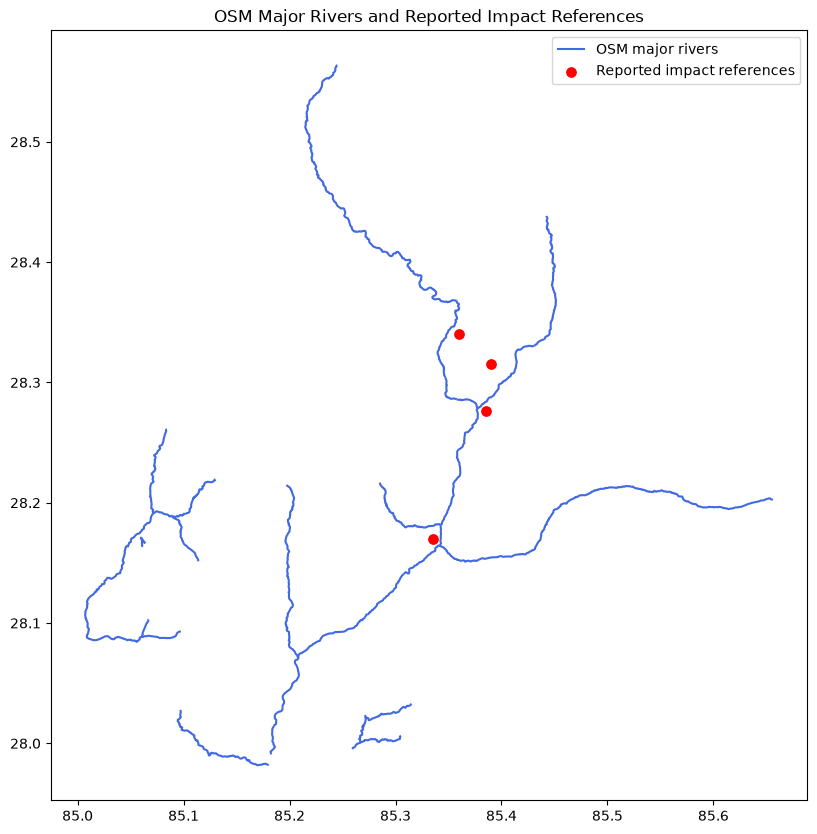

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))

rivers_gdf.plot(
    ax=ax,
    color="royalblue",
    linewidth=1.5,
    label="OSM major rivers",
)

impact_locations_gdf = gpd.GeoDataFrame(
    impact_locations,
    geometry=gpd.points_from_xy(
        impact_locations["longitude"],
        impact_locations["latitude"],
    ),
    crs="EPSG:4326",
)

impact_locations_gdf.plot(
    ax=ax,
    color="red",
    markersize=45,
    label="Reported impact references",
)

ax.legend()
ax.set_title(
    "OSM Major Rivers and Reported Impact References"
)
plt.show()

In [47]:
#selecting the relevant corridor
impact_locations_gdf = gpd.GeoDataFrame(
    impact_locations.copy(),
    geometry=gpd.points_from_xy(
        impact_locations["longitude"],
        impact_locations["latitude"],
    ),
    crs="EPSG:4326",
)

impact_locations_utm = impact_locations_gdf.to_crs(
    METRIC_CRS
)

In [48]:
impact_reference_union_utm = (
    impact_locations_utm
    .buffer(5_000)
    .union_all()
)

rivers_utm["near_reported_impact"] = (
    rivers_utm.geometry
    .intersects(impact_reference_union_utm)
)

relevant_rivers_utm = rivers_utm[
    rivers_utm["near_reported_impact"]
].copy()

print(
    "Relevant river features:",
    len(relevant_rivers_utm),
)

Relevant river features: 14


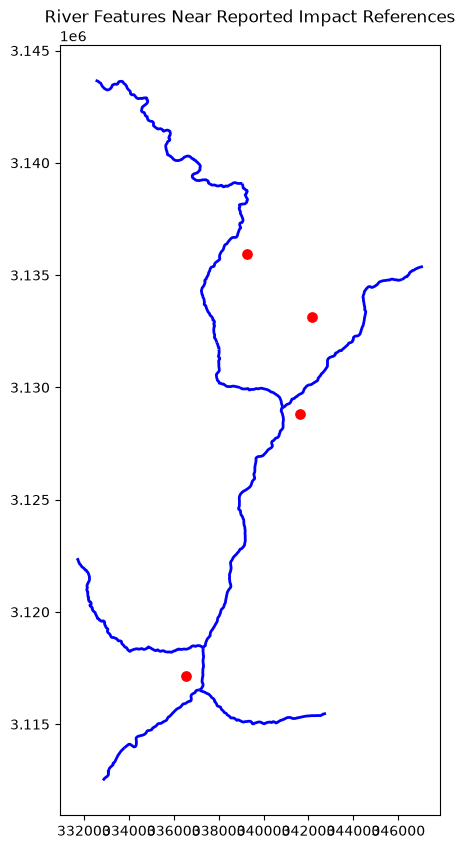

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))

relevant_rivers_utm.plot(
    ax=ax,
    color="blue",
    linewidth=2,
)

impact_locations_utm.plot(
    ax=ax,
    color="red",
    markersize=45,
)

ax.set_title(
    "River Features Near Reported Impact References"
)

plt.show()

In [55]:
relevant_rivers_gdf = (
    relevant_rivers_utm
    .drop(columns=["near_reported_impact"])
    .to_crs("EPSG:4326")
)

relevant_rivers_gdf.to_file(
    OSM_DIR / "relevant_rivers.geojson",
    driver="GeoJSON",
)

print(
    "Saved:",
    OSM_DIR / "relevant_rivers.geojson",
)

Saved: /Users/nishantanepal/Desktop/Data Analytics/nepal flood sentinel damage/data/external/osm/relevant_rivers.geojson


In [50]:
major_road_types = [
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "unclassified",
]

local_access_types = [
    "residential",
    "living_street",
    "service",
]

minor_path_types = [
    "path",
    "track",
    "footway",
    "steps",
]

In [51]:
def classify_road_type(value):
    if value in major_road_types:
        return "major_or_unclassified_road"
    if value in local_access_types:
        return "local_access"
    if value in minor_path_types:
        return "minor_path_or_track"
    return "other"

roads_gdf["road_group"] = (
    roads_gdf["highway"]
    .fillna("missing")
    .map(classify_road_type)
)

roads_gdf["road_group"].value_counts()

road_group
minor_path_or_track           2108
major_or_unclassified_road     536
local_access                   190
other                            3
Name: count, dtype: int64

In [52]:
roads_utm = roads_gdf.to_crs(METRIC_CRS)

buildings_utm = buildings_gdf.to_crs(METRIC_CRS)

buildings_utm = buildings_utm[
    buildings_utm.geometry.geom_type.isin(
        ["Polygon", "MultiPolygon"]
    )
].copy()

relevant_rivers_utm = relevant_rivers_utm[
    relevant_rivers_utm.geometry.geom_type.isin(
        ["LineString", "MultiLineString"]
    )
].copy()

In [53]:
river_buffer_sizes = [250, 500, 1000]

river_corridor_geometries = {}

for buffer_m in river_buffer_sizes:
    river_corridor_geometries[buffer_m] = (
        relevant_rivers_utm
        .buffer(buffer_m)
        .union_all()
    )

In [54]:
roads_gdf["road_group"].value_counts()

road_group
minor_path_or_track           2108
major_or_unclassified_road     536
local_access                   190
other                            3
Name: count, dtype: int64

In [56]:
#corridor sensitivity geometries
river_corridor_geometries = {}

for buffer_m in [250, 500, 1000]:
    river_corridor_geometries[buffer_m] = (
        relevant_rivers_utm
        .buffer(buffer_m)
        .union_all()
    )

In [57]:
river_corridor_summary = pd.DataFrame([
    {
        "buffer_m": buffer_m,
        "corridor_area_km2": (
            geometry.area / 1_000_000
        ),
    }
    for buffer_m, geometry
    in river_corridor_geometries.items()
])

river_corridor_summary

,buffer_m,corridor_area_km2
0,250,35.673747
1,500,70.256648
2,1000,137.992659


In [58]:
#exporting the flood candidate mask
candidate_export_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "flood_candidate_mask_3db.tif"
)

export_task = ee.batch.Export.image.toDrive(
    image=flood_candidate_mask.unmask(0).toByte(),
    description="nepal_flood_candidate_mask_3db",
    folder="nepal-flood-sentinel-damage",
    fileNamePrefix="flood_candidate_mask_3db",
    region=analysis_aoi,
    scale=10,
    maxPixels=1_000_000_000_000,
    fileFormat="GeoTIFF",
)

export_task.start()

print("Export task started.")
print("Check the Earth Engine Tasks tab for completion.")

Export task started.
Check the Earth Engine Tasks tab for completion.
